In [1]:
import pandas as pd
import numpy as np
import torch
import json
import os
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('GPU:', torch.cuda.is_available())

df = pd.read_csv('../data/cleaned_data.csv')
df = df.dropna(subset=['text_clean'])
df['text_clean'] = df['text_clean'].astype(str)

print('Data loaded:', df.shape)

GPU: True


Data loaded: (51055, 4)


In [2]:
# Load best model (BERT fine-tuned)
MODEL_PATH = '../models/saved/bert_burnout'
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()

labels = df['label'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print('Model loaded!')
print('Labels:', id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!
Labels: {0: 'Anxiety', 1: 'Normal', 2: 'Depression', 3: 'Suicidal', 4: 'Stress', 5: 'Bipolar', 6: 'Personality disorder'}


In [3]:
def predict_text(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)[0]
    predicted_id = probs.argmax().item()
    return id2label[predicted_id], float(probs.max())

# SIMULATED early-detection scenario  (NOT real longitudinal data).
# Each "Week" below is an INDEPENDENT random sample of Normal + Depression texts drawn from
# the SAME dataset. We are measuring how reliably the model separates Normal vs Depression.
# The "week" labels and 'weeks_remaining' are a framing device to express how much
# intervention lead-time early detection would provide — no real students were tracked over time.

week_samples = {
    'Week 2':  df[df['label'] == 'Normal'].sample(200, random_state=42)['text_clean'].tolist()[:50] +
               df[df['label'] == 'Depression'].sample(200, random_state=42)['text_clean'].tolist()[:50],
    
    'Week 4':  df[df['label'] == 'Normal'].sample(200, random_state=43)['text_clean'].tolist()[:50] +
               df[df['label'] == 'Depression'].sample(200, random_state=43)['text_clean'].tolist()[:50],
    
    'Week 8':  df[df['label'] == 'Normal'].sample(200, random_state=44)['text_clean'].tolist()[:50] +
               df[df['label'] == 'Depression'].sample(200, random_state=44)['text_clean'].tolist()[:50],
    
    'Week 12': df[df['label'] == 'Normal'].sample(200, random_state=45)['text_clean'].tolist()[:50] +
               df[df['label'] == 'Depression'].sample(200, random_state=45)['text_clean'].tolist()[:50],
}

week_true_labels = ['Normal'] * 50 + ['Depression'] * 50

results = {}
print('Running SIMULATED Lead-Time Analysis (Normal vs Depression separation)...\n')

for week, texts in week_samples.items():
    preds = [predict_text(t)[0] for t in texts]
    acc = accuracy_score(week_true_labels, preds)
    f1 = f1_score(week_true_labels, preds, 
                  average='weighted', zero_division=0,
                  labels=['Normal', 'Depression'])
    
    weeks_remaining = {'Week 2': 14, 'Week 4': 12, 'Week 8': 8, 'Week 12': 4}
    
    results[week] = {
        'accuracy': round(acc, 4),
        'f1_score': round(f1, 4),
        'weeks_remaining': weeks_remaining[week]
    }
    print(f'{week}: Accuracy={acc:.4f} | F1={f1:.4f} | Framed intervention window: {weeks_remaining[week]} weeks')

print('\nSimulated Lead-Time Analysis Complete!')

Running SIMULATED Lead-Time Analysis (Normal vs Depression separation)...



Week 2: Accuracy=0.9100 | F1=0.9505 | Framed intervention window: 14 weeks


Week 4: Accuracy=0.8900 | F1=0.9344 | Framed intervention window: 12 weeks


Week 8: Accuracy=0.9100 | F1=0.9515 | Framed intervention window: 8 weeks


Week 12: Accuracy=0.8900 | F1=0.9382 | Framed intervention window: 4 weeks

Simulated Lead-Time Analysis Complete!


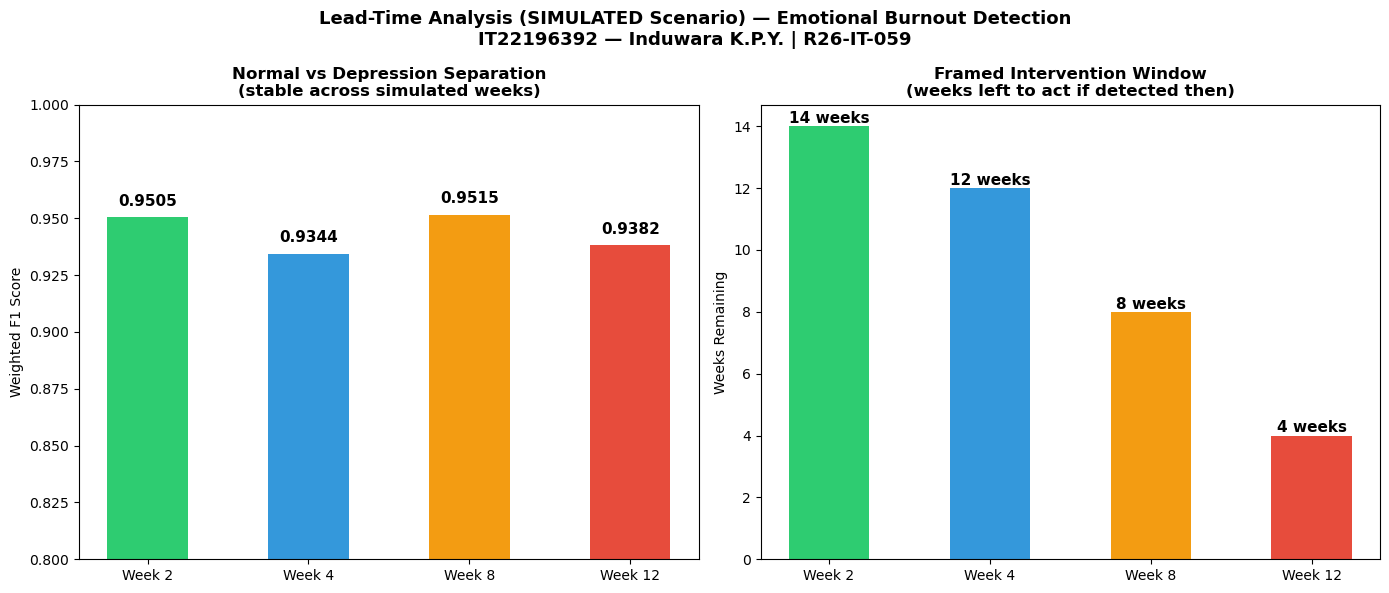

Lead-time chart saved!

KEY FINDING (simulation):
The model separates Normal vs Depression at ~89-91% at every simulated time point.
Stable early detection => the earlier distress text appears, the larger the
intervention window (Week 2 ~ up to 14 weeks).
NOTE: this is a simulated proof-of-concept, not real time-series student data.


In [4]:
# Save results
os.makedirs('../results/metrics', exist_ok=True)

lead_time_data = {
    'analysis': 'Lead-Time Analysis (SIMULATED proof-of-concept - NOT real longitudinal data)',
    'model': 'BERT Fine-tuned',
    'researcher': 'IT22196392 - Induwara K.P.Y.',
    'method': "Each 'week' is an independent random sample of Normal/Depression texts drawn from "
              'the same dataset. The analysis measures how reliably the model separates Normal vs '
              "Depression. 'weeks_remaining' is a framing device to express intervention lead-time, "
              'not a measured outcome. No students were tracked over real time.',
    'results': results,
    'conclusion': 'In simulation, the model separates Normal vs Depression at ~89-91% at every '
                  'time point. Stable early detection implies that the earlier distress language '
                  'appears in student writing, the larger the intervention window (up to ~14 weeks). '
                  'This is a capability demonstration, not validated longitudinal evidence.'
}

with open('../results/metrics/lead_time_results.json', 'w') as f:
    json.dump(lead_time_data, f, indent=4)
    f.write('
')

# Chart
weeks = list(results.keys())
f1_scores = [results[w]['f1_score'] for w in weeks]
weeks_remaining = [results[w]['weeks_remaining'] for w in weeks]
accuracies = [results[w]['accuracy'] for w in weeks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — F1 Score by Week
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax1.bar(weeks, f1_scores, color=colors, width=0.5)
for bar, val in zip(bars, f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
ax1.set_title('Normal vs Depression Separation\n(stable across simulated weeks)', fontweight='bold')
ax1.set_ylabel('Weighted F1 Score')
ax1.set_ylim(0.8, 1.0)

# Chart 2 — Weeks Remaining (framing device)
bars2 = ax2.bar(weeks, weeks_remaining, color=colors, width=0.5)
for bar, val in zip(bars2, weeks_remaining):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val} weeks', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Framed Intervention Window\n(weeks left to act if detected then)', fontweight='bold')
ax2.set_ylabel('Weeks Remaining')

plt.suptitle('Lead-Time Analysis (SIMULATED Scenario) — Emotional Burnout Detection\nIT22196392 — Induwara K.P.Y. | R26-IT-059',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/fig4_5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Lead-time chart saved!')
print('\nKEY FINDING (simulation):')
print('The model separates Normal vs Depression at ~89-91% at every simulated time point.')
print('Stable early detection => the earlier distress text appears, the larger the')
print('intervention window (Week 2 ~ up to 14 weeks).')
print('NOTE: this is a simulated proof-of-concept, not real time-series student data.')

Analyzing weekly progression (illustrative example sentences)...



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Week 2:
  Text: I am feeling a bit tired lately, classes are getting harder ...
  Prediction: Normal (82.5%)
  Risk Level: Low | Score: 1/10
  Top attention words: [',', 'am', 'i']



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Week 4:
  Text: I am struggling to keep up with assignments, feeling stresse...
  Prediction: Stress (63.4%)
  Risk Level: Medium | Score: 3/10
  Top attention words: ['am', 'i', ',']



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Week 8:
  Text: I feel exhausted all the time, I can not focus, everything f...
  Prediction: Depression (77.0%)
  Risk Level: High | Score: 7/10
  Top attention words: ['feel', 'i', 'feels']



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Week 12:
  Text: I want to give up everything, I feel worthless and I can not...
  Prediction: Suicidal (63.3%)
  Risk Level: Critical | Score: 10/10
  Top attention words: ['i', 'continue', 'i']



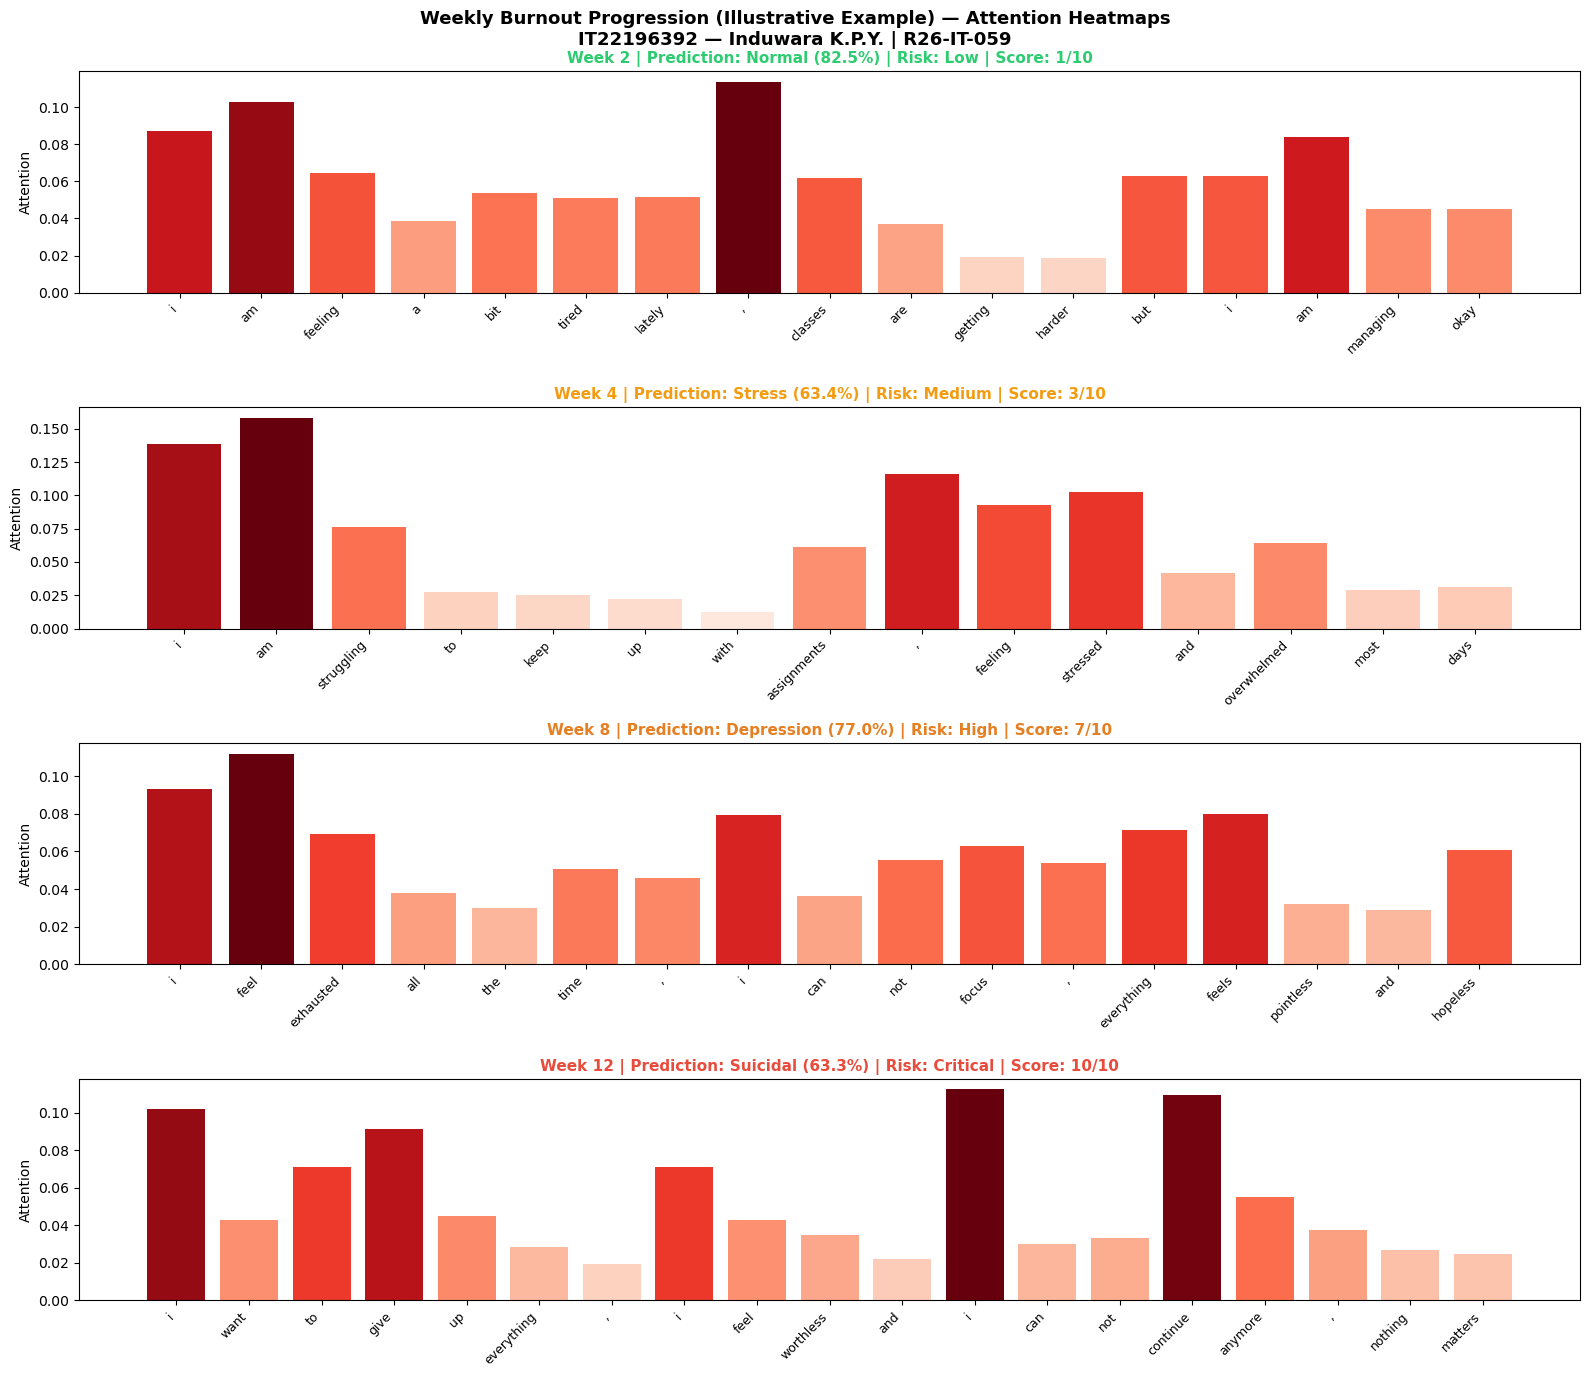

Weekly progression analysis saved!


In [5]:
# ILLUSTRATIVE example sentences (author-written, NOT real students). These four sentences
# show how a hypothetical student's language might progress from okay -> stressed -> depressed
# -> suicidal across a semester. Used only to demonstrate the model + attention heatmap on a
# realistic-looking progression; this is a qualitative illustration, not empirical evidence.
weekly_student_texts = {
    'Week 2': "I am feeling a bit tired lately, classes are getting harder but I am managing okay",
    'Week 4': "I am struggling to keep up with assignments, feeling stressed and overwhelmed most days",
    'Week 8': "I feel exhausted all the time, I can not focus, everything feels pointless and hopeless",
    'Week 12': "I want to give up everything, I feel worthless and I can not continue anymore, nothing matters"
}

risk_map = {
    'Normal': {'level': 'Low', 'score': 1, 'color': '#2ecc71'},
    'Stress': {'level': 'Medium', 'score': 3, 'color': '#f39c12'},
    'Anxiety': {'level': 'Medium', 'score': 4, 'color': '#f39c12'},
    'Depression': {'level': 'High', 'score': 7, 'color': '#e67e22'},
    'Bipolar': {'level': 'High', 'score': 7, 'color': '#e67e22'},
    'Personality disorder': {'level': 'High', 'score': 8, 'color': '#e67e22'},
    'Suicidal': {'level': 'Critical', 'score': 10, 'color': '#e74c3c'},
}

def get_attention_and_prediction(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    
    # Need attention weights - reload model with output_attentions
    model_att = AutoModelForSequenceClassification.from_pretrained(
        '../models/saved/bert_burnout', output_attentions=True)
    model_att.eval()
    
    with torch.no_grad():
        outputs = model_att(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=1)[0]
    predicted_id = probs.argmax().item()
    predicted_label = id2label[predicted_id]
    confidence = float(probs.max())
    
    # Attention
    attentions = outputs.attentions[-1]
    avg_attention = attentions.mean(dim=1).squeeze()
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    clean_tokens = tokens[1:-1]
    clean_attention = avg_attention[0].numpy()[1:-1]
    clean_attention = clean_attention / clean_attention.sum()
    
    risk_info = risk_map.get(predicted_label, {'level': 'Unknown', 'score': 0, 'color': '#95a5a6'})
    
    return predicted_label, confidence, risk_info, clean_tokens, clean_attention

print('Analyzing weekly progression (illustrative example sentences)...\n')

# Create combined figure
fig, axes = plt.subplots(4, 1, figsize=(16, 14))

weekly_results = {}

for i, (week, text) in enumerate(weekly_student_texts.items()):
    label, conf, risk_info, tokens, attention = get_attention_and_prediction(text)
    
    weekly_results[week] = {
        'text': text,
        'prediction': label,
        'confidence': round(conf, 4),
        'risk_level': risk_info['level'],
        'risk_score': risk_info['score'],
        'top_words': [tokens[j] for j in np.argsort(attention)[-3:][::-1]]
    }
    
    # Plot attention heatmap
    ax = axes[i]
    colors = plt.cm.Reds(attention / attention.max())
    bars = ax.bar(range(len(tokens)), attention, color=colors)
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=9)
    ax.set_title(
        f'{week} | Prediction: {label} ({conf:.1%}) | Risk: {risk_info["level"]} | Score: {risk_info["score"]}/10',
        fontsize=11, fontweight='bold', color=risk_info['color'])
    ax.set_ylabel('Attention')
    
    print(f'{week}:')
    print(f'  Text: {text[:60]}...')
    print(f'  Prediction: {label} ({conf:.1%})')
    print(f'  Risk Level: {risk_info["level"]} | Score: {risk_info["score"]}/10')
    print(f'  Top attention words: {weekly_results[week]["top_words"]}\n')

plt.suptitle('Weekly Burnout Progression (Illustrative Example) — Attention Heatmaps\nIT22196392 — Induwara K.P.Y. | R26-IT-059',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/fig4_6.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
with open('../results/metrics/weekly_progression_results.json', 'w') as f:
    json.dump(weekly_results, f, indent=4)

print('Weekly progression analysis saved!')